In [1]:
import sys
print(sys.executable)

/Users/mathur2585/Desktop/ML-Projects/project-1/ml_env/bin/python


## **Dataset**

### **Libraries Import**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Dataset Import**

In [2]:
data = pd.read_csv("/Users/mathur2585/Desktop/ML-Projects/project-1/data/raw/StudentsPerformance.csv")

data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### **Raw Data Stats**

#### **Dataset Dimensions**

In [3]:
data.shape

(1000, 8)

#### **Info about columns**

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


#### **Data stats**

In [5]:
data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### **Number of nulls in each column of Dataset**

In [6]:
data.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

### **Stats of resultant columns**

#### **Res column Description**

In [7]:
data[['math score','reading score','writing score']].describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### **Correlation between resultant columns**

In [8]:
data[['math score','reading score','writing score']].corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


#### **Mean of resultant columns w.r.t Test Preparation course status**

In [9]:
data.groupby("test preparation course")[["math score","reading score","writing score"]].mean()

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [12]:
prep_mean1 = data.groupby("test preparation course")[["math score","reading score","writing score"]].mean()
prep_mean1

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [13]:
prep_mean1.mean(axis=1)

test preparation course
completed    72.669460
none         65.038941
dtype: float64

#### **Mean of resultant columns w.r.t lunch status**

In [10]:
data.groupby("lunch")[["math score","reading score","writing score"]].mean()

,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


In [14]:
prep_mean2=data.groupby("lunch")[["math score","reading score","writing score"]].mean()
prep_mean2.mean(axis=1)

lunch
free/reduced    62.199061
standard        70.837209
dtype: float64

#### **Mean of resultant columns w.r.t parent level of education**

In [11]:
data.groupby("parental level of education")[["math score","reading score","writing score"]].mean()

,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


In [15]:
prep_mean3=data.groupby("parental level of education")[["math score","reading score","writing score"]].mean()

In [16]:
prep_mean3.mean(axis=1)

parental level of education
associate's degree    69.569069
bachelor's degree     71.923729
high school           63.096939
master's degree       73.598870
some college          68.476401
some high school      65.108007
dtype: float64

#### **Correlation of scores**

In [19]:
scores = data[["math score","reading score","writing score"]]
scores.corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


#### **Score Correlation Heatmap**

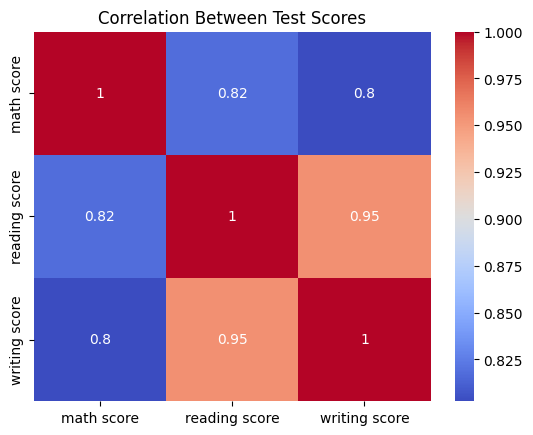

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = scores.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Test Scores")
plt.show()

#### **Boxplots plotting effects of various factors on math scores**

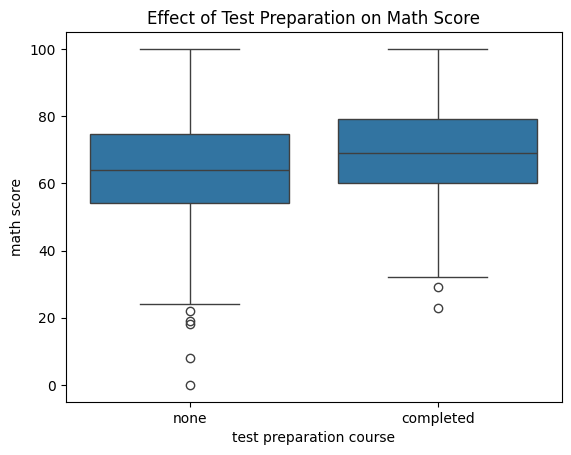

In [21]:
sns.boxplot(x="test preparation course", y="math score", data=data)
plt.title("Effect of Test Preparation on Math Score")
plt.show()

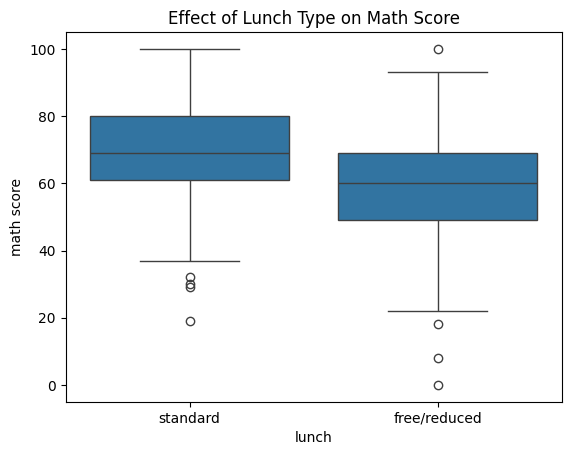

In [22]:
sns.boxplot(x="lunch", y="math score", data=data)
plt.title("Effect of Lunch Type on Math Score")
plt.show()

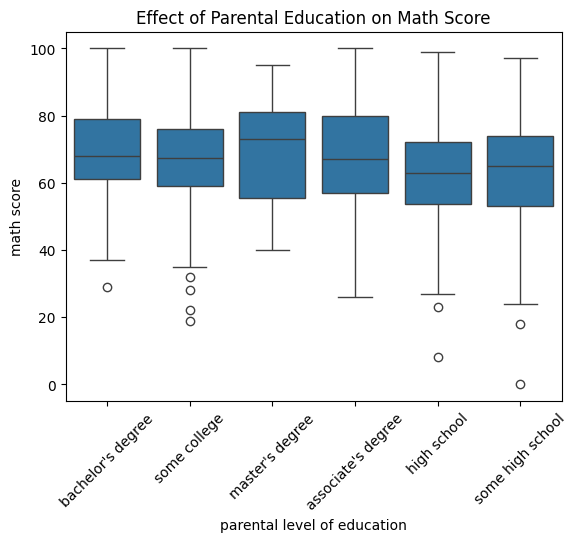

In [23]:
sns.boxplot(x="parental level of education", y="math score", data=data)
plt.xticks(rotation=45)
plt.title("Effect of Parental Education on Math Score")
plt.show()

| Feature            | Mean gap         | Visual separation  |
| ------------------ | ---------------- | ------------------ |
| parental education | largest          | heavy overlap      |
| lunch              | slightly smaller | clearer separation |


**Lunch type shows a clear difference in academic performance groups. (stronger predictor)**

**Parental education has some influence, but it does not strongly separate student performance groups. (weak–moderate predictor)**

#### **Pairplot within scores**

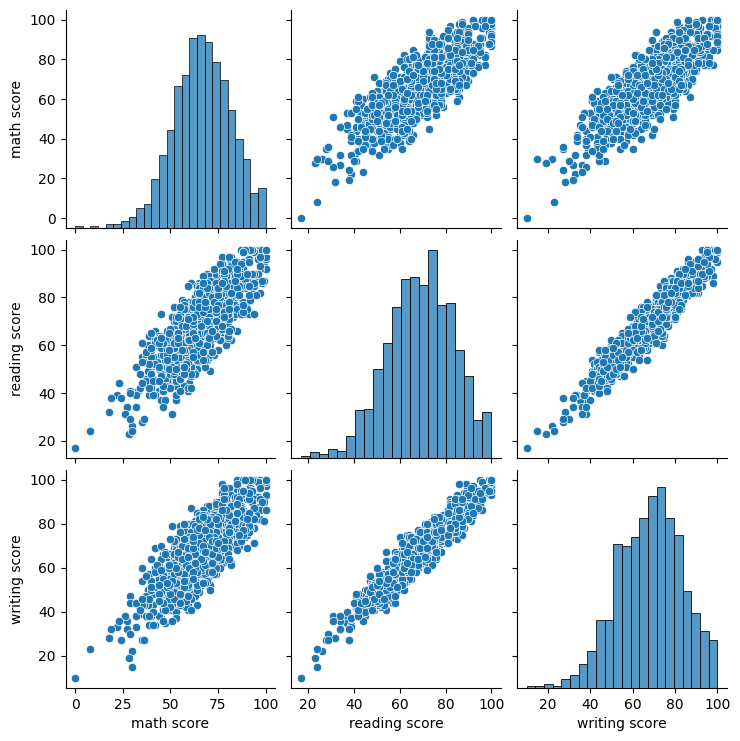

In [24]:
sns.pairplot(data[["math score","reading score","writing score"]])

### **Overall Score Stats**

In [25]:
data["overall_score"] = data[["math score","reading score","writing score"]].mean(axis=1)

data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,overall_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


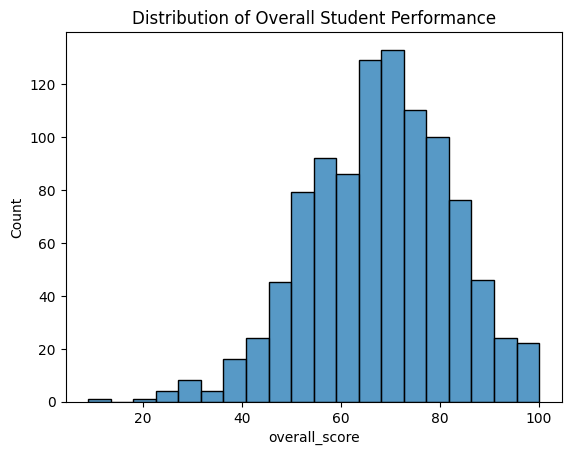

In [30]:
sns.histplot(data["overall_score"], bins=20)
plt.title("Distribution of Overall Student Performance")
plt.show()

### **Combined Language Score**

In [27]:
data["language_score"] = data[["reading score","writing score"]].mean(axis=1)

#### **Math Score vs Language Correlation**

In [28]:
data[["math score","language_score"]].corr()

,math score,language_score
math score,1.000000,0.819311
language_score,0.819311,1.000000


#### **Scatter Plot (CLS)**

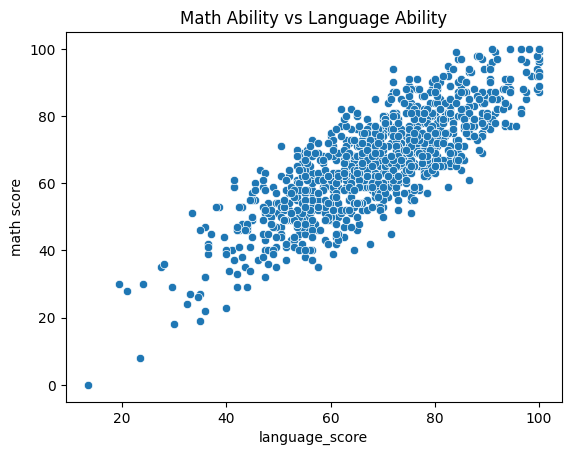

In [29]:
sns.scatterplot(x="language_score", y="math score", data=data)
plt.title("Math Ability vs Language Ability")
plt.show()

**Students good at language tend to be somewhat good at math, but the relationship is not extremely strong.**